In [ ]:
# utils
import pickle
import numpy as np
import pandas as pd
from pathlib import Path

#sk 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import KFold
from sklearn.cluster import KMeans

#plot
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd 


### One basin, with timeline

##### Technical procedure:
- get cell states (predictors) and matching temp timeseries (target) (matching regarding the 365 warmup and also the inherent availability of discharge data maybe use dates)
- split into train- and test-set and train, return R² and RMSE 

_notes:_
- _don't return dataset, but return model and metadata (train period, test period, metrics)_

In [59]:
with open("/home/wuhlmann/BA/data/processed_data/cell_states/full_q_512_3011_185525_cell_states.p", "rb") as f: 
	cell_states = pickle.load(f)

In [60]:
with open("/home/wuhlmann/BA/data/processed_data/eda/normal_periods.pkl", "rb") as f: 
	discharge_coverage = pickle.load(f)

In [61]:
discharge_coverage.loc[1,:]

timeseries_length                                                     8036
start_date                                             1996-01-01 00:00:00
end_date                                               2017-12-31 00:00:00
n_normal_days                                                         7098
q5_q95_normal_periods    [[1996-01-04 00:00:00, 1996-01-05 00:00:00], [...
Name: 1, dtype: object

In [ ]:
ts_path = Path("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/2_timeseries")

diff of ts and c len: 0
R2 of 0.93 | MAE of 1.470405110258113
R2 of 0.93 | MAE of 1.454923040853074
R2 of 0.93 | MAE of 1.532552804976333
R2 of 0.93 | MAE of 1.5399377085958013
R2 of 0.93 | MAE of 1.4477447723646504
diff of ts and c len: 0
R2 of 0.90 | MAE of 1.9187086850135833
R2 of 0.92 | MAE of 1.7481938045213126
R2 of 0.91 | MAE of 1.9252409475700154
R2 of 0.91 | MAE of 1.8765682311120728
R2 of 0.90 | MAE of 2.0018861085387902


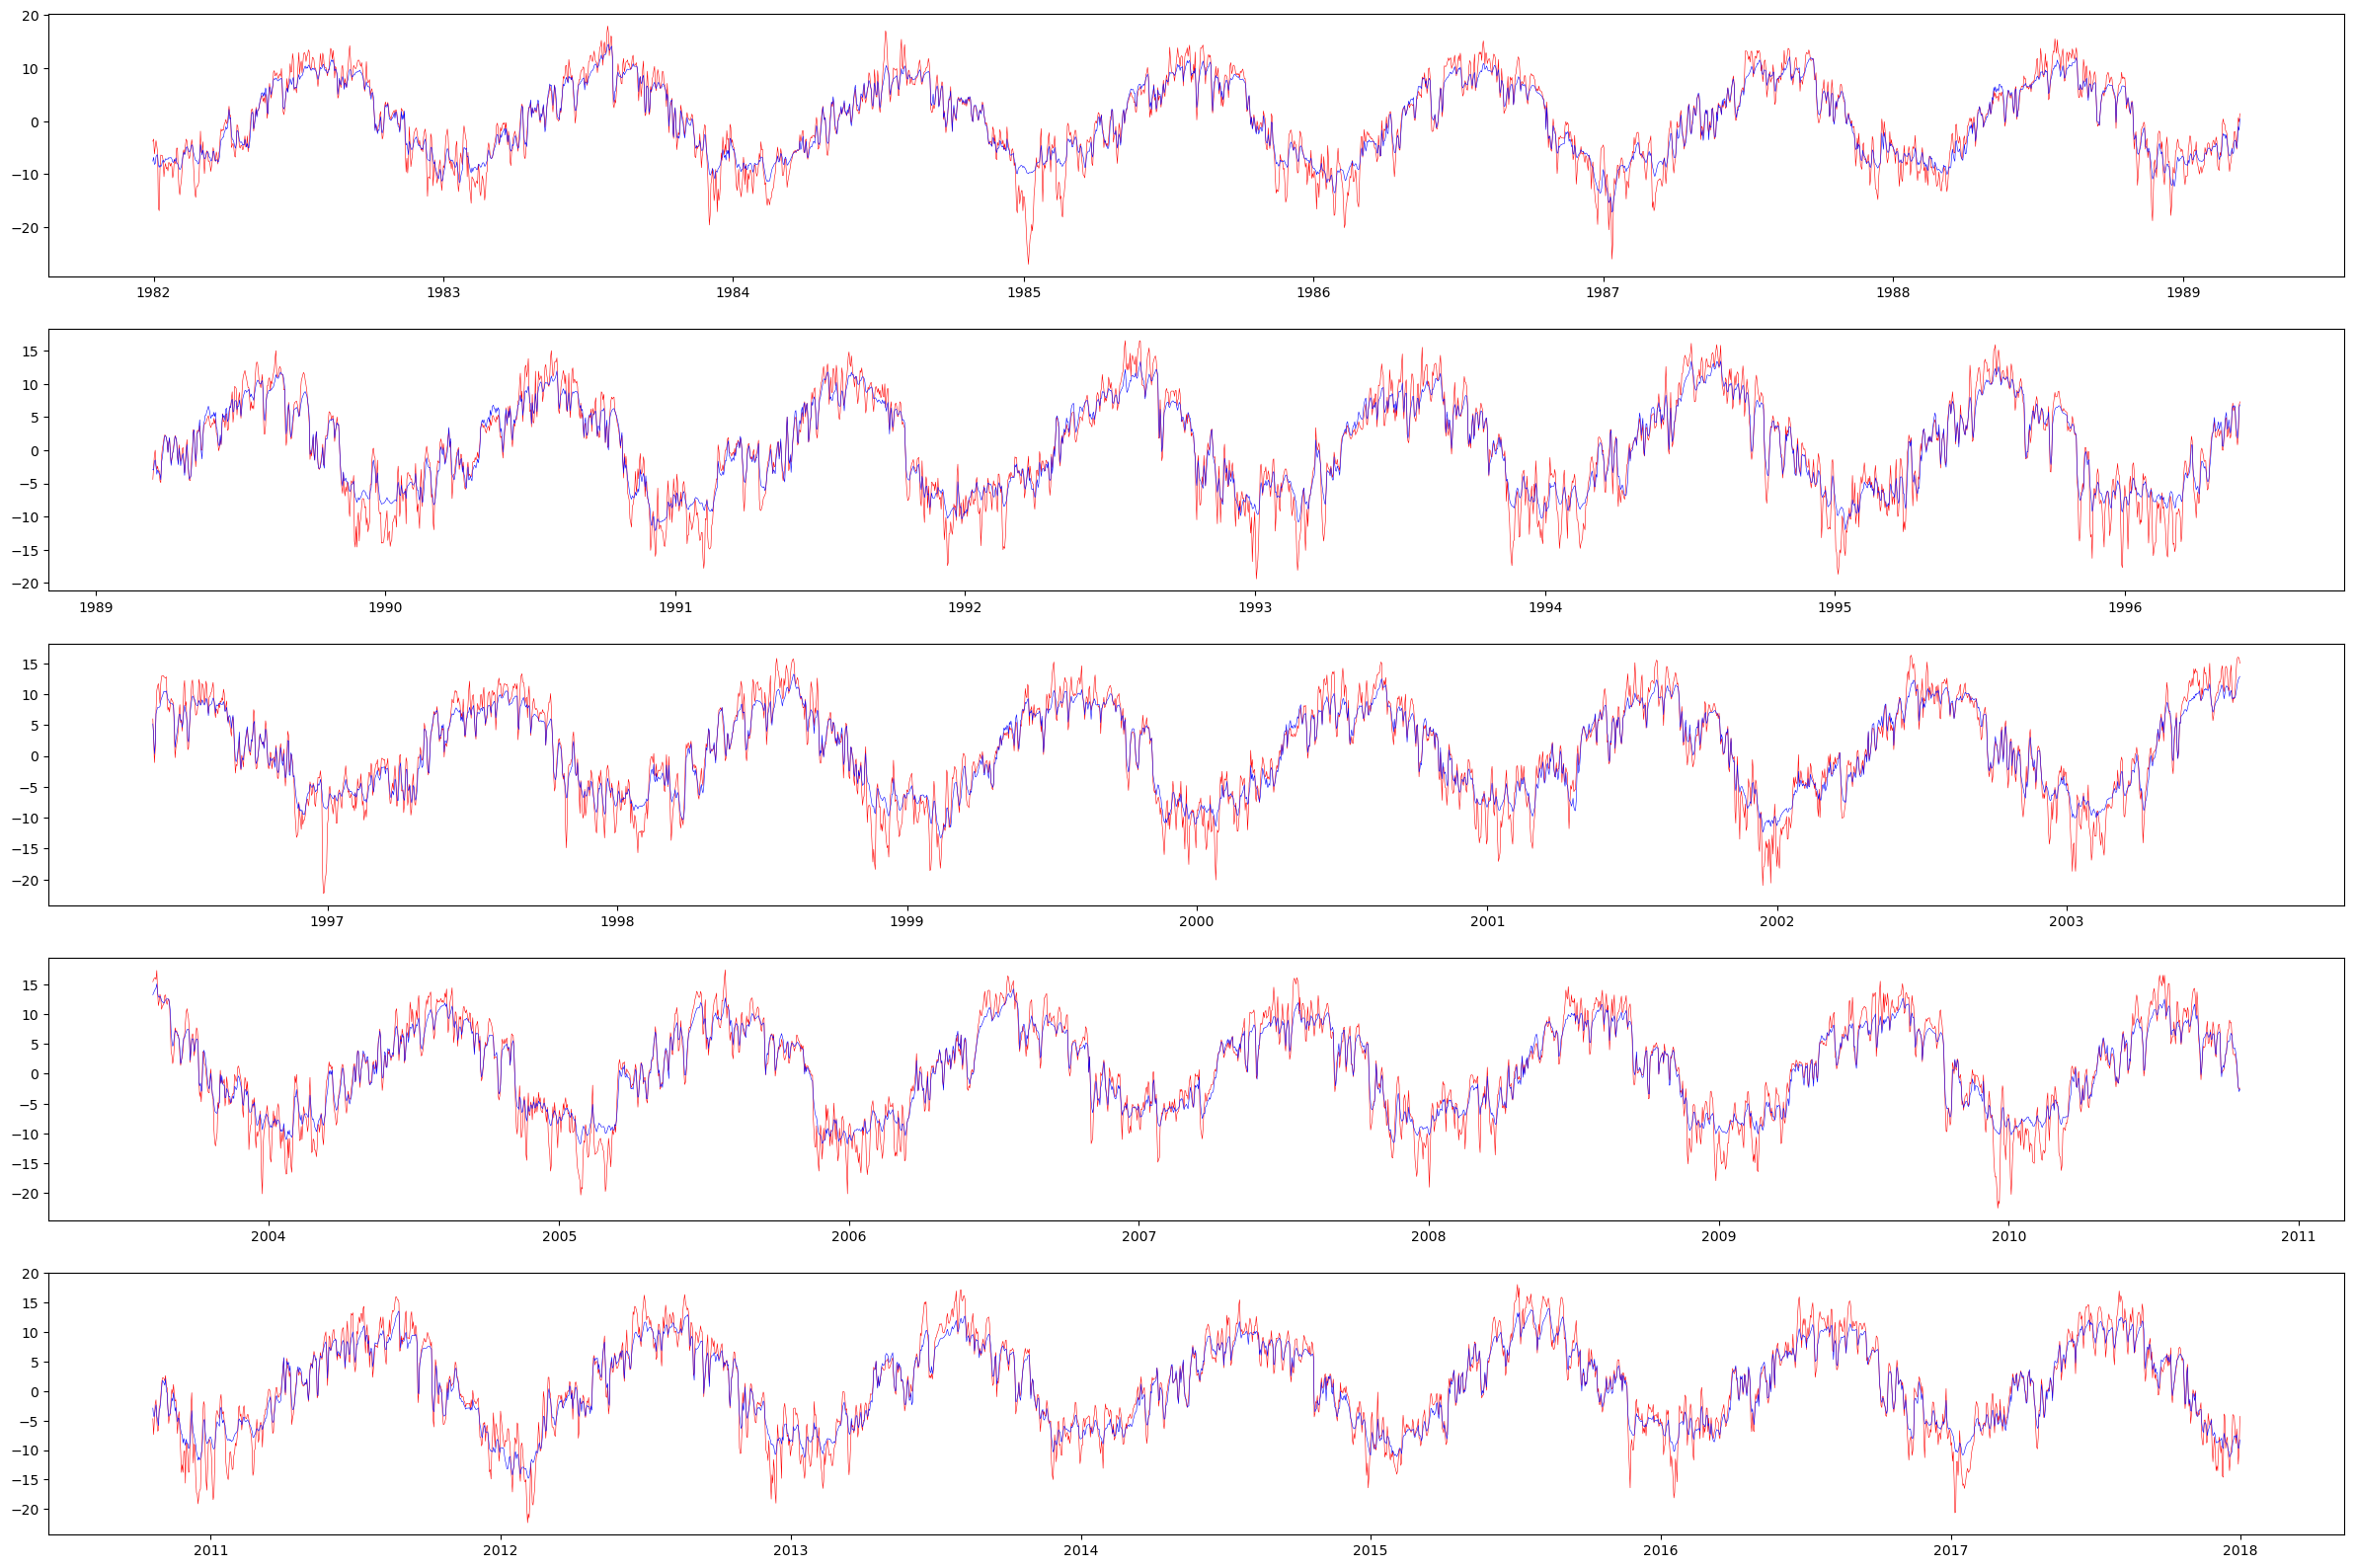

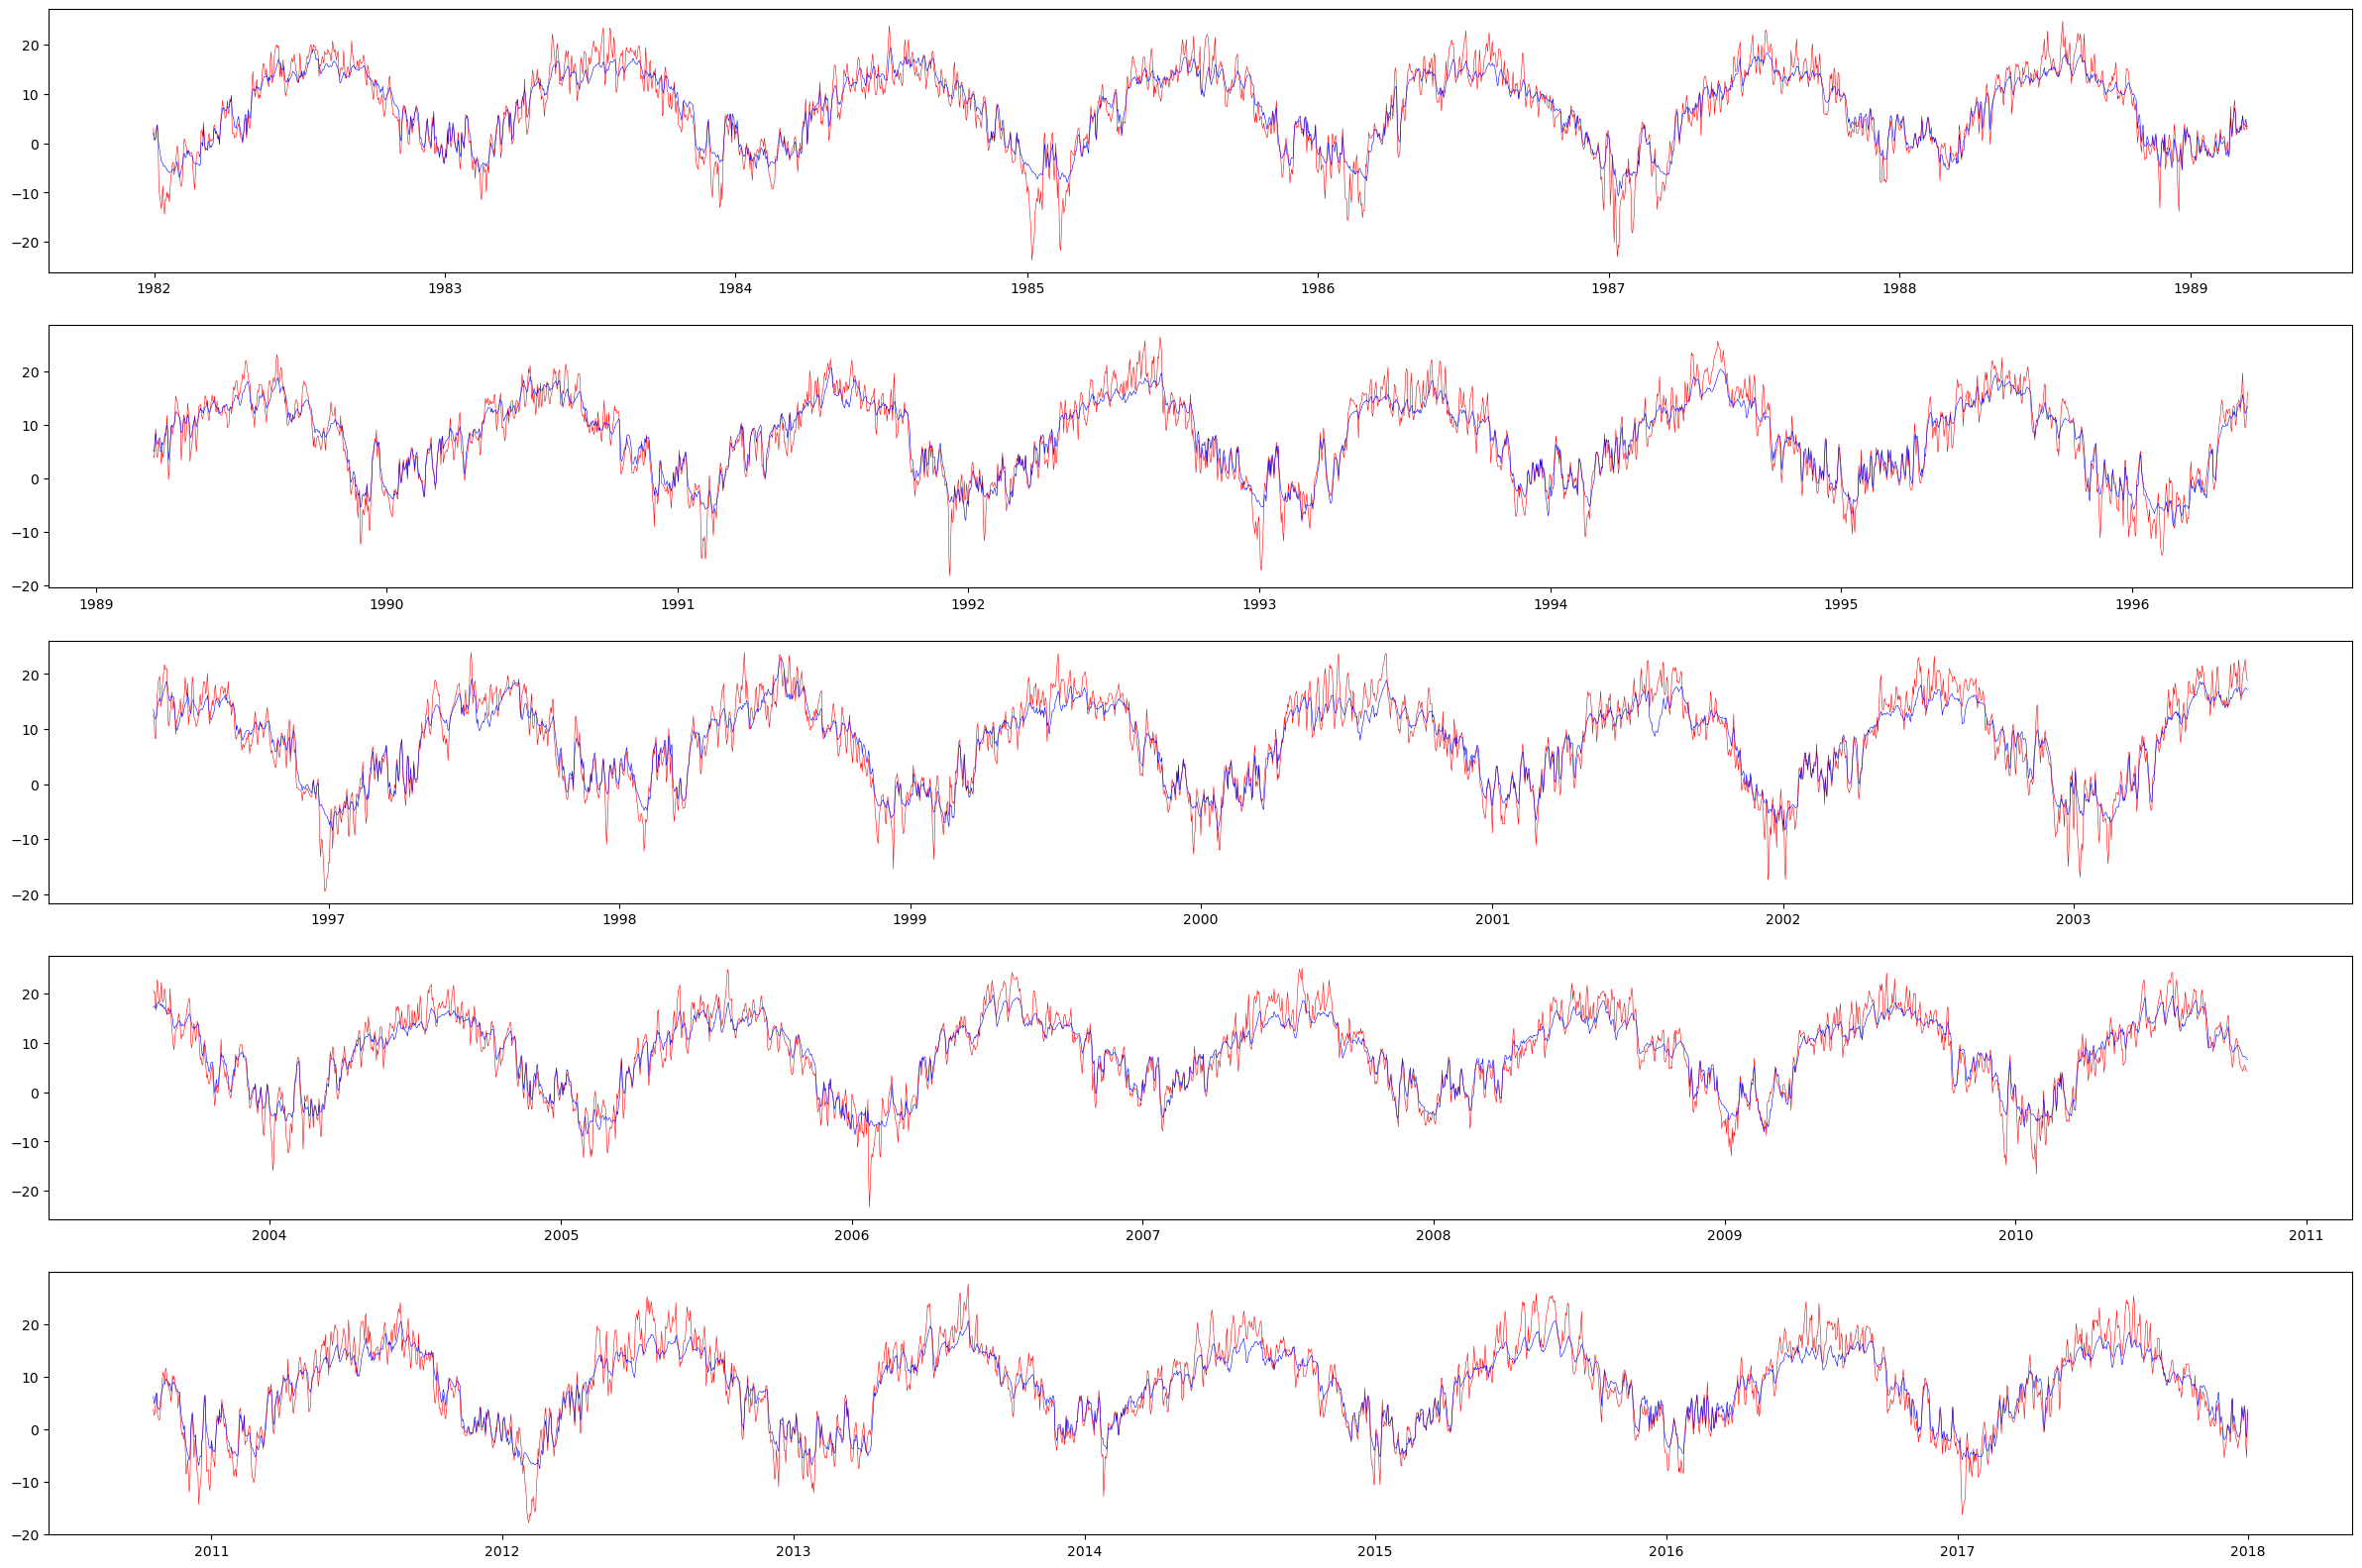

In [63]:
path = Path("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/2_timeseries/daily")
model_coef = []

for basin_id in [115, 834]: 

	ts = pd.read_table(ts_path / f"ID_{basin_id}.csv", header=0, sep=";")

	ts["date"] = pd.to_datetime(
				ts[["YYYY", "MM", "DD"]].rename(columns={"YYYY": "year", "MM": "month", "DD": "day"})
			)
	ts.set_index("date", inplace=True)

	# drop all columns except for 2m_mean_temp
	ts = ts[["2m_temp_mean"]]

	ts  = ts[discharge_coverage.loc[basin_id,"start_date"]:discharge_coverage.loc[basin_id, "end_date"]]
	c = StandardScaler().fit_transform(cell_states[str(basin_id)]["c_last"])
	
	ts =ts.iloc[-len(c):]
	
	print(f"diff of ts and c len: {len(ts) -len(c)}")
	dataset = np.c_[c, ts.values]

	model = ElasticNet()
	kfold = KFold(n_splits=5)
	folds = list(kfold.split(dataset[:,:-1], dataset[:,-1]))

	fig, axs = plt.subplots(5,1, figsize=(30,20))

	best_r2 = -100
	best_model_id = None
	coef_list = []

	for i, f, ax in zip([0,1,2,3,4],folds, axs):
		
		train_ids = f[0]
		test_ids = f[1]

		target = dataset[:,-1][test_ids]

		model.fit(X=dataset[:,:-1][train_ids], y=dataset[:,-1][train_ids])
		pred = model.predict(X=dataset[:,:-1][test_ids])

		coef_list.append(model.coef_)

		r2 = r2_score(target, pred)

		if r2 > best_r2: 
			best_r2 = r2
			best_model_id = i

		print(f"R2 of {r2:.2f} | MAE of {mean_absolute_error(target, pred)}")

		ax.plot(ts.index[test_ids], target, color="red", linewidth=0.4)
		ax.plot(ts.index[test_ids], pred, color="blue", linewidth=0.4)

	model_coef.append(coef_list[best_model_id])


we use c of day of prediction, since it most acuratly represents the condition of the day the model predicts

### Basin probes

In [111]:
with open("/home/wuhlmann/BA/data/processed_data/probing/full_q_512_3011_185525_cell_states_2m_temp_mean_basin_probe.p", "rb") as f: 
	temp_basin_probe_results = pickle.load(f)

with open("/home/wuhlmann/BA/data/processed_data/probing/full_q_512_3011_185525_cell_states_prec_basin_probe.p", "rb") as f: 
	prec_basin_probe_results = pickle.load(f)

with open("/home/wuhlmann/BA/data/processed_data/probing/full_q_512_3011_185525_cell_states_total_et_basin_probe.p", "rb") as f: 
	total_et_basin_probe_results = pickle.load(f)

with open("/home/wuhlmann/BA/data/processed_data/probing/full_q_512_3011_185525_cell_states_swe_basin_probe.p", "rb") as f: 
	swe_basin_probe_results = pickle.load(f)

temp Always on: Index([46, 91, 98, 156], dtype='int64') 
Always off: Index([0, 37, 52, 61, 82, 96, 103, 108, 118, 132, 133, 205, 218], dtype='int64')

prec Always on: Index([], dtype='int64') 
Always off: Index([  0,   4,   5,   9,  10,  16,  26,  31,  36,  37,  45,  46,  51,  52,
        54,  58,  62,  67,  78,  81,  84,  85,  86,  87,  88,  89,  91,  93,
        97,  99, 101, 106, 110, 118, 119, 120, 121, 122, 126, 131, 132, 134,
       137, 140, 144, 147, 148, 158, 161, 162, 163, 164, 169, 170, 173, 174,
       181, 186, 188, 194, 195, 196, 202, 205, 206, 211, 213, 215, 216, 220,
       222, 237, 244, 249, 251],
      dtype='int64')

total_et Always on: Index([], dtype='int64') 
Always off: Index([  0,   1,   6,   7,  12,  19,  20,  21,  25,  30,  32,  37,  47,  50,
        52,  57,  58,  61,  73,  82,  83,  84,  99, 103, 108, 117, 118, 122,
       125, 130, 132, 133, 135, 137, 141, 144, 153, 159, 164, 165, 168, 175,
       178, 182, 185, 186, 187, 197, 200, 202, 205, 208, 210, 212,

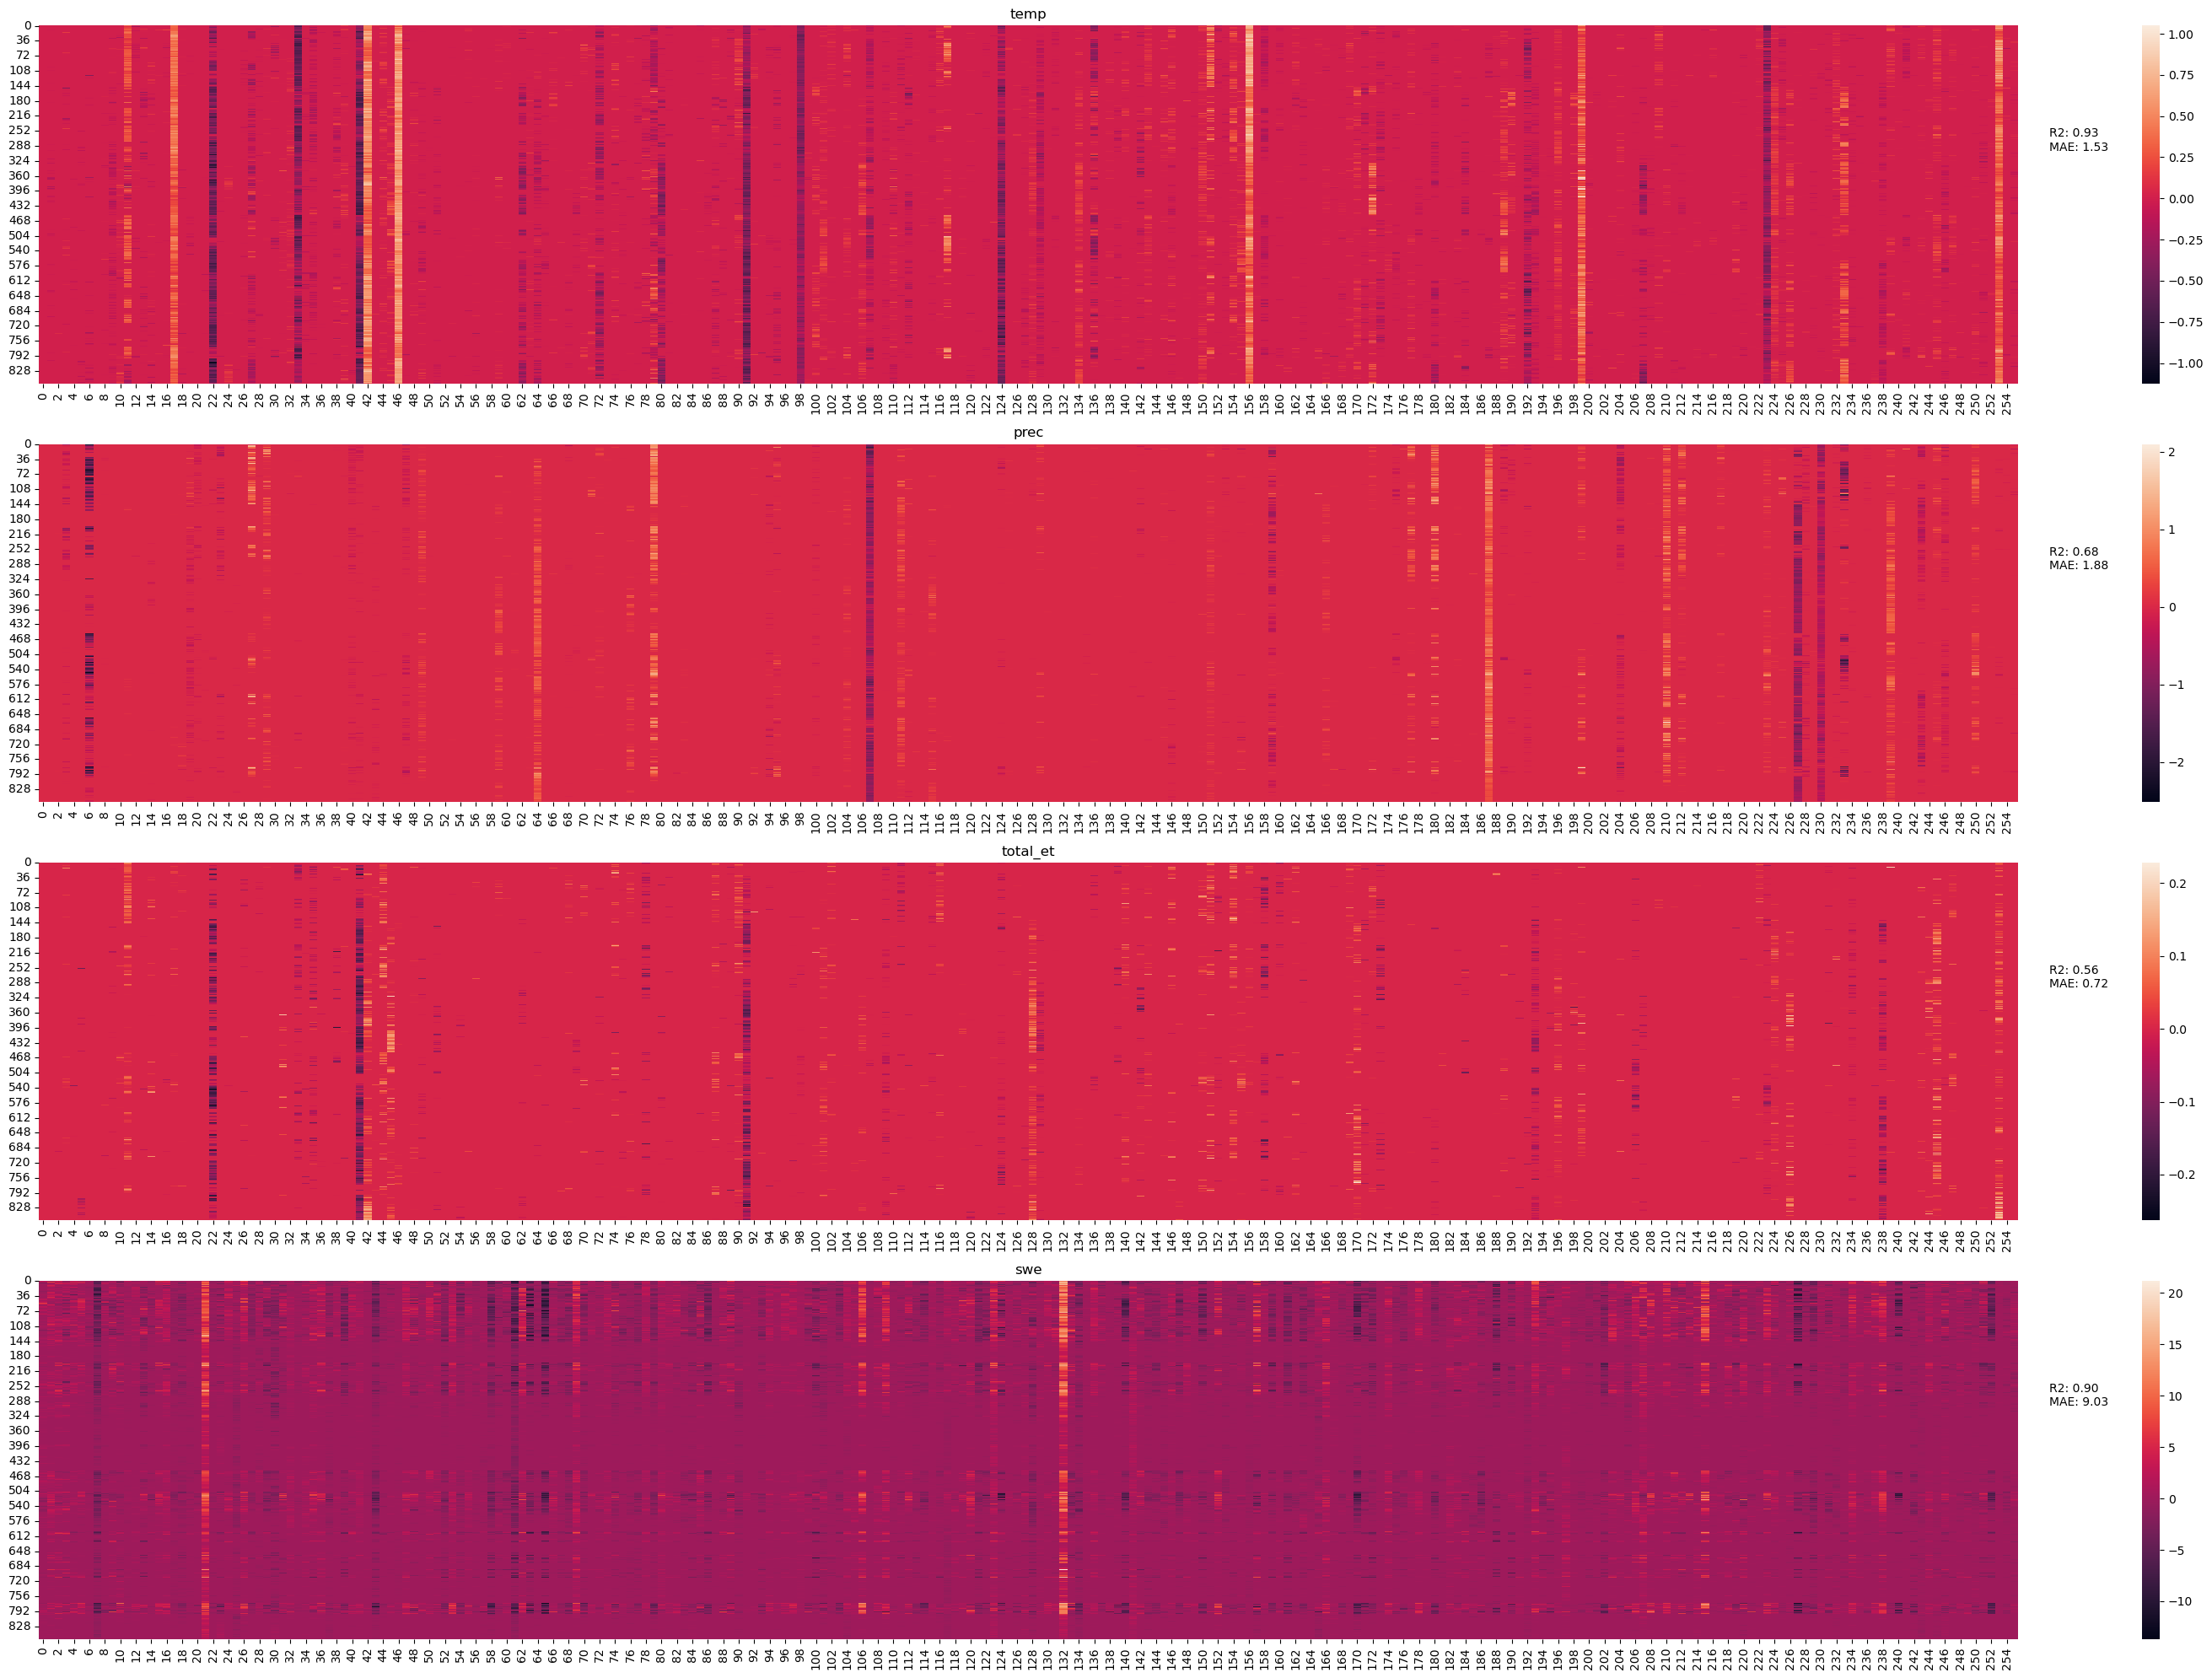

In [137]:
fig, axs = plt.subplots(4,1, figsize=(30,20))

for ax, probe, name in zip(
    axs,[temp_basin_probe_results, prec_basin_probe_results, total_et_basin_probe_results, swe_basin_probe_results],
    ["temp", "prec", "total_et", "swe"]
):

	rtwos = [probe[b]["R2"] for b in probe.keys()]
	maes = [probe[b]["MAE"] for b in probe.keys()]
	weights = [probe[b]["coef"] for b in probe.keys()]
	w_stack = np.vstack(weights)

	sns.heatmap(w_stack, ax=ax)
	ax.text(x=260, y=300, s=f"R2: {np.mean(rtwos):.2f} \nMAE: {np.mean(maes):.2f}")
	ax.set_title(name)

	weights_df = pd.DataFrame(w_stack)
	always_on= (weights_df != 0).all()
	always_off = (weights_df == 0).all()
	print(f"{name} Always on: {always_on.index[always_on]} \nAlways off: {always_off.index[always_off]}\n")

fig.savefig("/home/wuhlmann/BA/repo/lamah-ce_lstm/results/basin_probe_weights.png", dpi=300)

plt.tight_layout()



In [128]:
#load .shp and sort index 
lamah_gdf = gpd.read_file("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/3_shapefiles/Basins_B.shp")
lamah_gdf.set_index("ID", inplace=True)
lamah_gdf.sort_index(ascending=True, inplace=True)

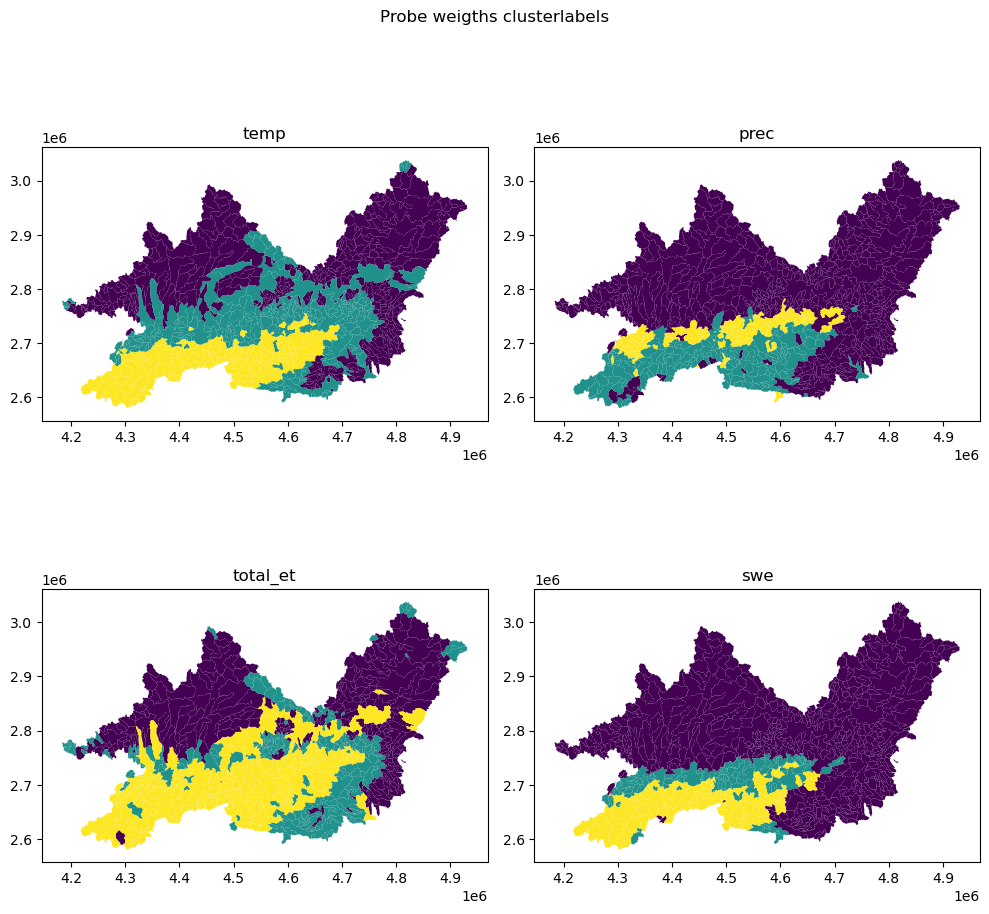

In [138]:
fig, axs = plt.subplots(2,2, figsize=(10,10))
fig.suptitle("Probe weigths clusterlabels")
kmeans = KMeans(3, random_state=42)

for ax, probe, name in zip(
	axs.ravel(),
	[temp_basin_probe_results, prec_basin_probe_results, total_et_basin_probe_results, swe_basin_probe_results],
	["temp", "prec", "total_et", "swe"]
	):

	weights = [probe[b]["coef"] for b in probe.keys()]
	w_stack = np.vstack(weights)
	weights_df = pd.DataFrame(w_stack)
	
	probe_weights_labels = kmeans.fit_predict(weights_df)	

	col = f"{name}_labels"
	lamah_gdf[col] = probe_weights_labels
	lamah_gdf.plot(column=col, ax=ax)
	ax.set_title(f"{name}")


fig.savefig("/home/wuhlmann/BA/repo/lamah-ce_lstm/results/basin_probe_weigths_cluster.png", dpi=300)
plt.tight_layout()

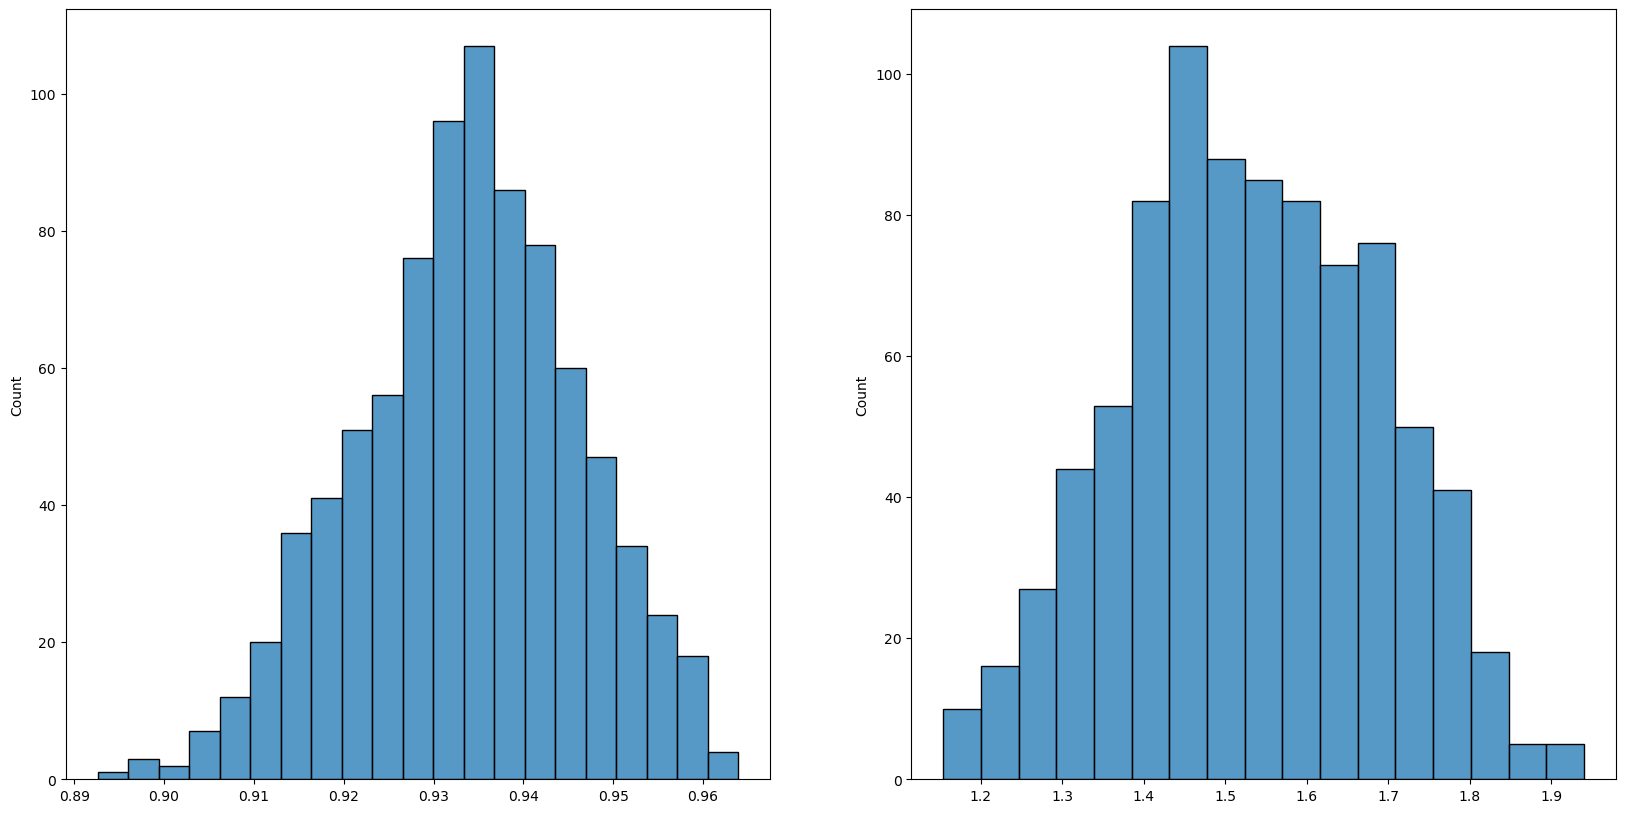

In [69]:
fig, axs = plt.subplots(1,2, figsize=(20,10))

for ax, metric in zip(axs, [rtwos, maes]): 
    
	sns.histplot(metric, ax=ax)

### Domain probes

Note: original study could only train probe for swe, after filtering out non-snow-melt basins.

In [93]:
with open("/home/wuhlmann/BA/data/processed_data/probing/full_q_512_3011_185525_cell_states_2m_temp_mean_domain_probe.p", "rb") as f: 
    temp_domain_probe_results = pickle.load(f)

with open("/home/wuhlmann/BA/data/processed_data/probing/full_q_512_3011_185525_cell_states_prec_domain_probe.p", "rb") as f: 
    prec_domain_probe_results = pickle.load(f)

with open("/home/wuhlmann/BA/data/processed_data/probing/full_q_512_3011_185525_cell_states_total_et_domain_probe.p", "rb") as f: 
    total_et_domain_probe_results = pickle.load(f)

with open("/home/wuhlmann/BA/data/processed_data/probing/full_q_512_3011_185525_cell_states_swe_domain_probe.p", "rb") as f: 
    swe_domain_probe_results = pickle.load(f)

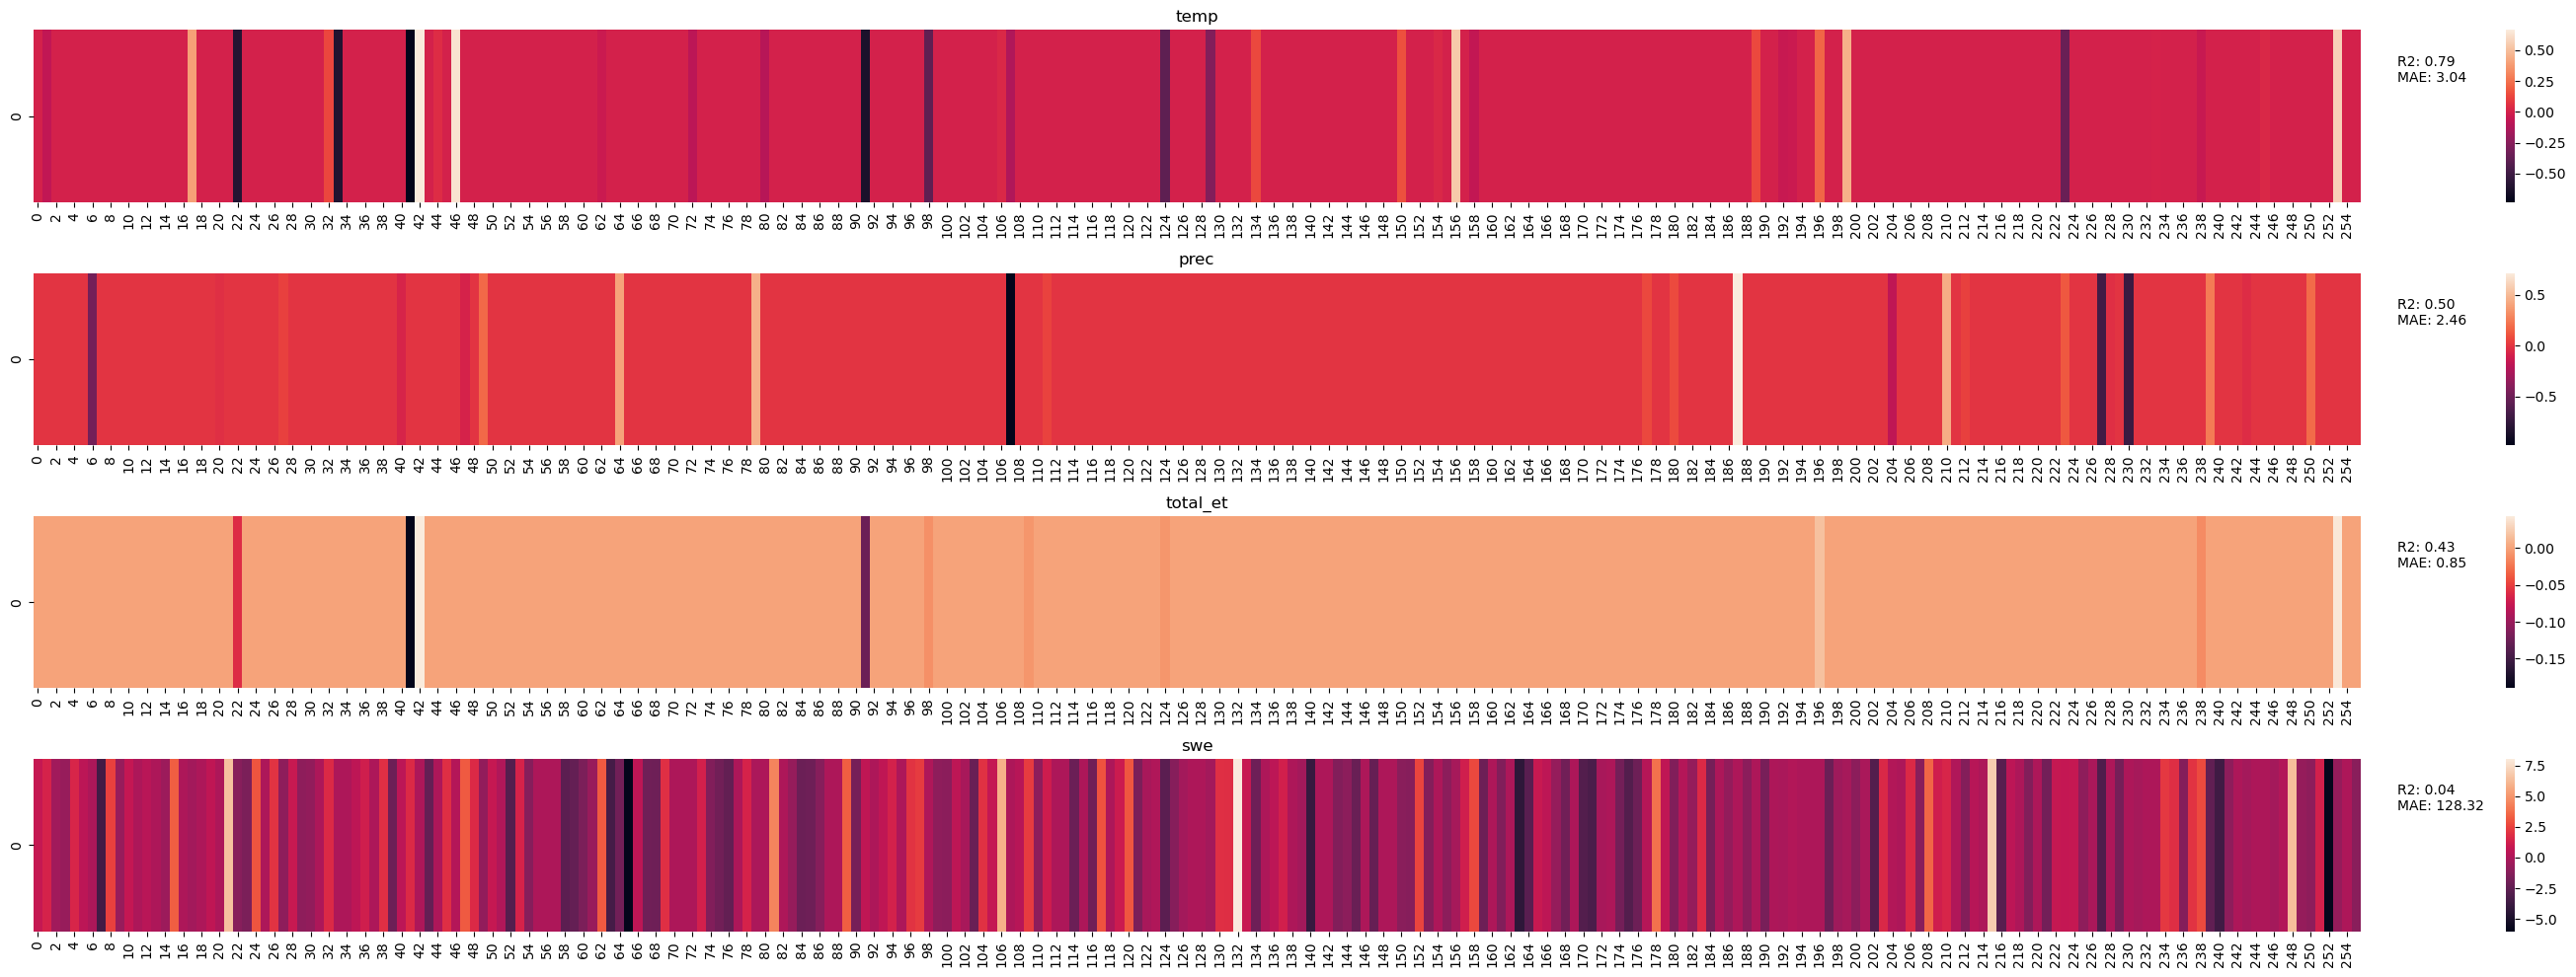

In [ ]:
fig, axs = plt.subplots(4,1, figsize=(30,10))

for ax, probe, name in zip(
	axs.ravel(),
	[temp_domain_probe_results, prec_domain_probe_results, total_et_domain_probe_results, swe_domain_probe_results],
	["temp", "prec", "total_et", "swe"]):

	sns.heatmap(np.reshape(probe["train_results"]["model"].coef_,(1,256)), ax=ax)
	ax.text(x=260, y=0.3, s=f"R2: {probe['train_results']['R2']:.2f} \nMAE: {probe['train_results']['MAE']:.2f}")
	ax.set_title(name)


plt.tight_layout()

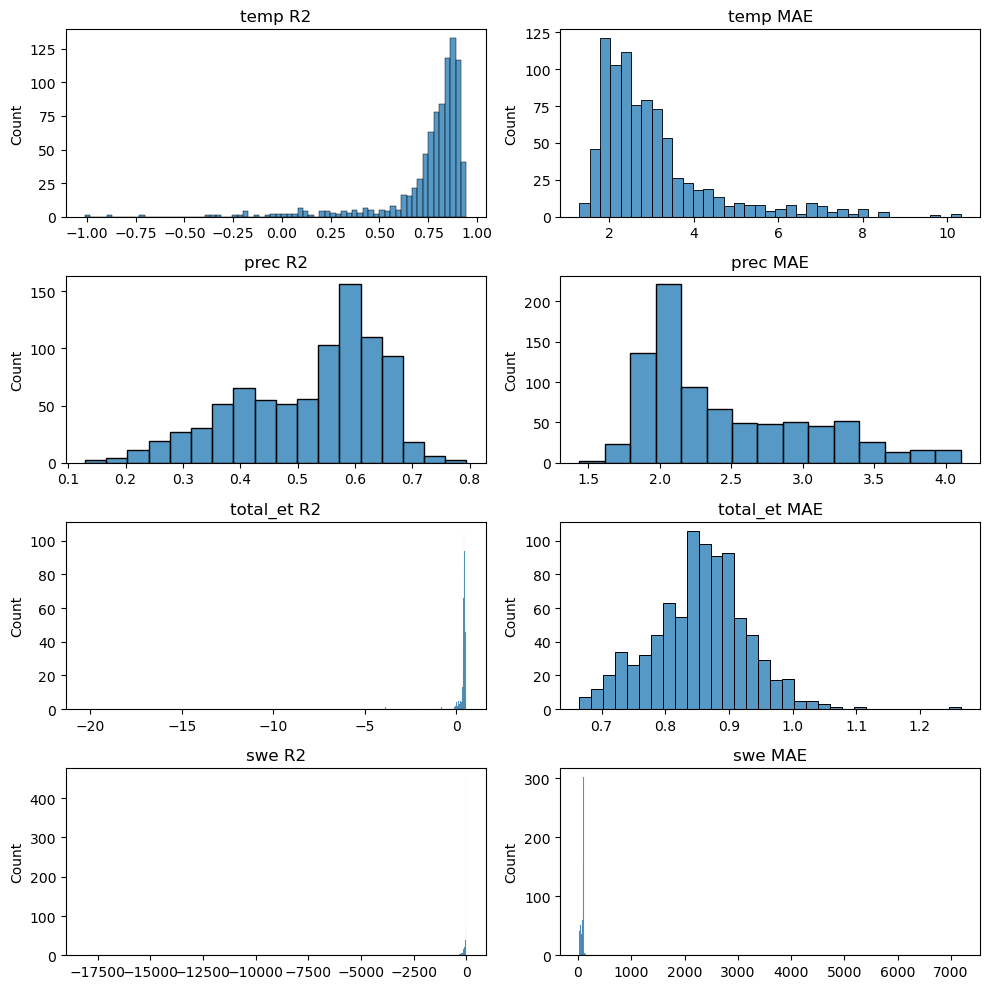

In [109]:
fig, axs = plt.subplots(4,2, figsize=(10,10))
axs = axs.ravel()

for i, probe, name in zip(
	list(range(0,8,2)),
	[temp_domain_probe_results, prec_domain_probe_results, total_et_domain_probe_results, swe_domain_probe_results],
	["temp", "prec", "total_et", "swe"]
	):
	 
	basin_keys = list(probe.keys())[1:]

	basins_r2 = [probe[b]["R2"] for b in basin_keys]
	basins_mae = [probe[b]["MAE"] for b in basin_keys]

	sns.histplot(basins_r2, ax=axs[i])
	axs[i].set_title(f"{name} R2")
	sns.histplot(basins_mae, ax=axs[i+1])
	axs[i+1].set_title(f"{name} MAE")

plt.tight_layout()